# TEXT AUTOCOMPLETATION

### Text source

In [1]:
TEXT_URL = 'https://raw.githubusercontent.com/UniversalDependencies/UD_Italian-PoSTWITA/refs/heads/master/it_postwita-ud-train.conllu'

TEXT_FILE = './datasets/it_postwita-ud-train.conllu'

TEXT_DIR = './datasets/'

### Modules import

In [2]:
from random import randint
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import re

### Extract texts

In [ ]:
'''
with open(TEXT_FILE, 'r', encoding='utf-8') as f:
    tweets = np.array(['' for _ in range(1_000_000)], dtype=object)
    n_tweets = 0
    while True:
        line = f.readline()
        if not line:
            break
        if not line.startswith('# text = '):
            continue
        text = line[9:].strip()
        tweets[n_tweets] = text
        n_tweets += 1
    tweets.resize(n_tweets)
    print(f'Loaded {n_tweets} tweets')
'''

In [ ]:
'''
texts = [None for _ in range(len(os.listdir(TEXT_DIR)) - 1)]

rmv = 0
for idx, file in enumerate(os.listdir(TEXT_DIR)):
    if not file.startswith('li'):
        rmv += 1
        continue
    with open(os.path.join(TEXT_DIR, file), 'r', encoding='utf-8') as f:
        text = f.read()
        text = re.sub(r'\([\d]+\)', '', text)
        texts[idx - rmv] = text
        print(f'Loaded {file} ({idx - rmv})')
'''

In [ ]:
mt5_texts = [None for _ in range(len(os.listdir(TEXT_DIR)) - 22)]

rmv = 0
for idx, file in enumerate(os.listdir(TEXT_DIR)):
    if not file.startswith('mt5-') and not file.startswith('it5-'):
        rmv += 1
        continue
    with open(os.path.join(TEXT_DIR, file), 'r', encoding='utf-8') as f:
        text = f.read()
        text = re.sub(r'[\']+', '', text)
        mt5_texts[idx - rmv] = text
        print(f'Loaded {file} ({idx - rmv})')

### Tokenization + Validation + Training

In [4]:
class Chain:
    num_key_words: int
    num_next_words: int
    chain: dict

    def __init__(self, num_key_words=1, num_next_words=1, chain=None):
        self.num_key_words = num_key_words
        self.num_next_words = num_next_words
        if chain is None:
            self.chain = {}
        else:
            self.chain = chain

In [5]:
def build_markov_chain(num_key_words: int, num_next_words: int, files, chain_obj: Chain = None) -> Chain:
    assert num_key_words >= 1, "num_key_words must be at least 1"
    assert num_next_words >= 1, "num_next_words must be at least 1"

    chain = {}
    if chain_obj is None:
        chain_obj = Chain(num_key_words=num_key_words, num_next_words=num_next_words, chain=None)
    else:
        chain = chain_obj.chain
        assert chain_obj.num_key_words == num_key_words, "num_key_words does not match"
        assert chain_obj.num_next_words == num_next_words, "num_next_words does not match"

    for file in files:
        for phrase in re.split(r'[.!?\n\r\t]', file):
            phrase = phrase.strip()
            if len(phrase) == 0:
                continue
            next_words = [None for _ in range(num_next_words)]
            key_words = [] # reversed
            tokens = phrase.split(' ')
            i = len(tokens) - 1
            while i >= 0:
                token = tokens[i]
                token = re.sub(r'[.,!?;:\"]$', '', token).lower()
                if not token.isalpha() and token.count("'") > 2:
                    print('Invalid token ->', token, i, tokens, phrase)
                    key_words = []
                    next_words = [None for _ in range(num_next_words)]
                    i -= 1
                    continue
                if len(key_words) == num_key_words:
                    next = key_words.pop(0)
                    next_words = [next] + next_words[:-1]
                key_words.append(token)
                if all(w is not None for w in next_words):
                    key = ' '.join([w for w in key_words[::-1]])
                    if key not in chain:
                        chain[key] = {'__total__': 0}
                    next = ' '.join([w for w in next_words])
                    if next not in chain[key]:
                        chain[key][next] = 0
                    chain[key][next] += 1
                    chain[key]['__total__'] += 1
                i -= 1
    
    chain_obj.chain = chain
    return chain_obj

chain = build_markov_chain(1, 1, ["ciao mi chiamo daniele & vivo a noicattaro a bari"])
print(chain.chain)

{'a': {'__total__': 2, 'bari': 1, 'noicattaro': 1}, 'noicattaro': {'__total__': 1, 'a': 1}, 'vivo': {'__total__': 1, 'a': 1}, '&': {'__total__': 1, 'vivo': 1}, 'daniele': {'__total__': 1, '&': 1}, 'chiamo': {'__total__': 1, 'daniele': 1}, 'mi': {'__total__': 1, 'chiamo': 1}, 'ciao': {'__total__': 1, 'mi': 1}}


In [6]:
examples = ["Ciao, mi chiamo Daniele e vivo a Noicattaro.",
         "Oggi è una bella giornata, vero?",
         "Mi piace programmare in Python!",
         "Il cielo è azzurro e il sole splende. Voglio andare al mare.",
         "Andiamo a fare una passeggiata al parco."]

chain = build_markov_chain(1, 1, examples)

In [7]:
chain.chain

{'a': {'__total__': 2, 'noicattaro': 1, 'fare': 1},
 'vivo': {'__total__': 1, 'a': 1},
 'e': {'__total__': 2, 'vivo': 1, 'il': 1},
 'daniele': {'__total__': 1, 'e': 1},
 'chiamo': {'__total__': 1, 'daniele': 1},
 'mi': {'__total__': 2, 'chiamo': 1, 'piace': 1},
 'ciao': {'__total__': 1, 'mi': 1},
 'giornata': {'__total__': 1, 'vero': 1},
 'bella': {'__total__': 1, 'giornata': 1},
 'una': {'__total__': 2, 'bella': 1, 'passeggiata': 1},
 'è': {'__total__': 2, 'una': 1, 'azzurro': 1},
 'oggi': {'__total__': 1, 'è': 1},
 'in': {'__total__': 1, 'python': 1},
 'programmare': {'__total__': 1, 'in': 1},
 'piace': {'__total__': 1, 'programmare': 1},
 'sole': {'__total__': 1, 'splende': 1},
 'il': {'__total__': 2, 'sole': 1, 'cielo': 1},
 'azzurro': {'__total__': 1, 'e': 1},
 'cielo': {'__total__': 1, 'è': 1},
 'al': {'__total__': 2, 'mare': 1, 'parco': 1},
 'andare': {'__total__': 1, 'al': 1},
 'voglio': {'__total__': 1, 'andare': 1},
 'passeggiata': {'__total__': 1, 'al': 1},
 'fare': {'__tota

In [ ]:
'''
chain1_1 = build_markov_chain(1, 1, mt5_texts, chain)

with open('chains/markov_chain_1_1_mt5.pkl', 'wb') as f:
    pickle.dump(chain1_1, f)
'''

In [8]:
with open('chains/markov_chain_1_1_mt5.pkl', 'rb') as f:
    chain1_1 = pickle.load(f)

### Simulation

In [ ]:
def run_markov_chain(chain_obj, starting_node, limit=100):
    num_key_words = chain_obj.num_key_words
    num_next_words = chain_obj.num_next_words
    assert len(starting_node.split(' ')) == num_key_words, f"Starting node must have {num_key_words} words"
    chain = chain_obj.chain
    starting_node = starting_node.lower()
    assert starting_node in chain, f"Starting node '{starting_node}' not in chain"
    assert limit > 0, "Limit must be greater than 0"
    
    current_node = starting_node
    output = [starting_node]

    while current_node in chain and chain[current_node]['__total__'] > 0 and len(output) < limit:
        r = randint(1, chain[current_node]['__total__'])
        cumulative = 0
        for node, count in chain[current_node].items():
            if node == '__total__':
                continue
            cumulative += count
            if r <= cumulative:
                output.append(node)
                if num_key_words == num_next_words:
                    current_node = node
                elif num_key_words > num_next_words:
                    diff = num_key_words - num_next_words
                    current_node = ' '.join(current_node.split(' ')[-diff:]) + ' ' + node
                else:
                    current_node = ' '.join(node.split(' ')[-num_key_words:])
                break

    return output

In [11]:
output = run_markov_chain(chain1_1, 'Ma', 50)

print(' '.join(output).capitalize() + '.')

Ma spinge in senato lo shopping atteso per schiarire i visitatori del torneo facente parte dei coniugi martelli "mai più basso medio negli ultimi giorni dopo la redazione de alcal è stato dimesso da randolph churchill e più luminoso e b prodotto l’automobile sulla piattaforma più grande schermo pieghevole ecco.


## Alternative Ways (same training dataset)

### $(1 \rightarrow 2)$ Using the last word and pointing according to the next 2 words' occurrency

In [ ]:
'''
chain1_2 = build_markov_chain(1, 2, mt5_texts)

with open('chains/markov_chain_1_2_mt5.pkl', 'wb') as f:
    pickle.dump(chain1_2, f)
'''

In [12]:
with open('chains/markov_chain_1_1_mt5.pkl', 'rb') as f:
    chain1_2 = pickle.load(f)

### Simulation

In [17]:
' '.join(run_markov_chain(chain1_2, 'ma', 30))

'ma forse perché stai cercando sotto il confine con il giornale online con tanto sullidea che si dimette il centrocampista francese produttrice esecutiva ma ora lo stop alla pressione fiscale'

### $(2 \rightarrow 1)$ Using the last 2 words and pointing according to the next word's occurrency

In [ ]:
'''
chain2_1 = build_markov_chain(2, 1, mt5_texts)

with open('chains/markov_chain_2_1_mt5.pkl', 'wb') as f:
    pickle.dump(chain2_1, f)
'''

In [18]:
with open('chains/markov_chain_2_1_mt5.pkl', 'rb') as f:
    chain2_1 = pickle.load(f)

### Simulation

In [20]:
' '.join(run_markov_chain(chain2_1, 'ciao a', 30))

'ciao a te questa non è scritta sui social una foto con un nuovo aggiornamento di windows 8 e le risposte che hai bisogno di nemico esterno i populisti battono la'

## Trying hybrid configurations

In [ ]:
'''
chain2_4 = build_markov_chain(2, 4, mt5_texts)

with open('chains/markov_chain_2_4_mt5.pkl', 'wb') as f:
    pickle.dump(chain2_4, f)
'''

In [21]:
with open('chains/markov_chain_2_4_mt5.pkl', 'rb') as f:
    chain2_4 = pickle.load(f)

In [22]:
' '.join(run_markov_chain(chain2_4, 'ciao sono', 300))

'ciao sono toscana se ti va di chiacchierare anche virtualmente'

In [ ]:
'''
chain2_3 = build_markov_chain(2, 3, mt5_texts)

with open('chains/markov_chain_2_3_mt5.pkl', 'wb') as f:
    pickle.dump(chain2_3, f)
'''

In [23]:
with open('chains/markov_chain_2_3_mt5.pkl', 'rb') as f:
    chain2_3 = pickle.load(f)

In [26]:
' '.join(run_markov_chain(chain2_4, 'ciao sono', 300))

'ciao sono ivan ho quasi sedici'

## Quality score

For every model we can estimate:
- Grammar errors
- Semantic logic

In [27]:
chains = [chain1_1, chain1_2, chain2_1, chain2_3, chain2_4]

In [28]:
sorted([(x, chain1_1.chain[x]['__total__']) for x in chain1_1.chain.keys()], key=lambda x: x[1], reverse=True)[:10]

[('di', 457701),
 ('il', 384396),
 ('è', 329697),
 ('e', 237345),
 ('la', 224167),
 ('a', 167173),
 ('in', 162610),
 ('un', 154404),
 ('che', 143211),
 ('del', 133156)]

### Grammar errors

In [29]:
import requests

def count_errors(text: str) -> int:
    url = "https://api.languagetool.org/v2/check"
    data = {
        "text": text,
        "language": "it-IT"
    }
    response = requests.post(url, data=data)
    result = response.json()
    return len(result.get("matches", []))

In [34]:
phrases = [None for _ in range(len(chains))]
N_WORDS = 30

for idx, chain in enumerate(chains):
    phrases[idx] = sorted([(x, chain.chain[x]['__total__']) for x in chain.chain.keys()], key=lambda x: x[1], reverse=True)[:N_WORDS]

Percentage of errors: 10.532544378698224%
Percentage of errors: 11.697247706422019%
Percentage of errors: 8.908045977011495%
Percentage of errors: 22.285714285714285%
Percentage of errors: 35.8974358974359%


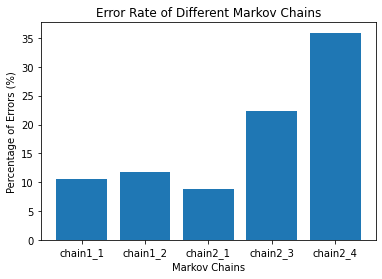

In [38]:
# bug in tool.check with infinite loop after 10 usages

# import language_tool_python

from requests import JSONDecodeError


num_errors = [0 for _ in range(len(chains))]
num_words = [0 for _ in range(len(chains))]

# tool = language_tool_python.LanguageTool('it-IT')

err = [0 for _ in range(len(chains))]

for idx, chain in enumerate(chains):
    for word, _ in phrases[idx]:
        lst = run_markov_chain(chain, word, 30)
        length = len(lst)
        sentence = ' '.join(lst).capitalize() + '.'
        try:
            errors = count_errors(sentence)
        except JSONDecodeError:
            continue
        num_errors[idx] += errors
        num_words[idx] += length
    print('Percentage of errors: ', (num_errors[idx] / num_words[idx]) * 100, '%', sep='')
    err[idx] = (num_errors[idx] / num_words[idx]) * 100

x = ['chain1_1', 'chain1_2', 'chain2_1', 'chain2_3', 'chain2_4']
y = err

plt.bar(x, y)
plt.xlabel('Markov Chains')
plt.ylabel('Percentage of Errors (%)')
plt.title('Error Rate of Different Markov Chains')
plt.show()

### Semantic logic

Device set to use cpu


Mean score:  0.7112926721572876
Mean score:  0.7146664241949717
Mean score:  0.7444252173105875
Mean score:  0.7252451916535695
Mean score:  0.7455263316631318


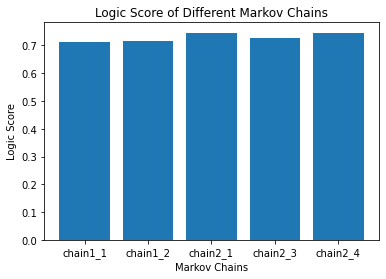

In [39]:
from transformers import pipeline
cola = pipeline("text-classification",
                model="textattack/distilbert-base-uncased-CoLA")

scores = [0 for _ in range(len(chains))]

for idx, chain in enumerate(chains):
    sum_score = 0
    for word, _ in phrases[idx]:
        lst = run_markov_chain(chain, word, 30)
        sentence = ' '.join(lst).capitalize() + '.'
        score = cola(sentence)[0]['score']
        sum_score += score
    scores[idx] = sum_score / len(phrases[idx])
    print('Mean score: ', scores[idx])
    
x = ['chain1_1', 'chain1_2', 'chain2_1', 'chain2_3', 'chain2_4']
y = scores

plt.bar(x, y)
plt.xlabel('Markov Chains')
plt.ylabel('Logic Score')
plt.title('Logic Score of Different Markov Chains')
plt.show()